CAPSTONE TOPIC: TELECOM CHURN MODEL
NAME: OGU UGOCHUKWU MONDAY
FELLOW ID: FE/25/5766333919
COHORT: NEXTGEN
STATE: LAGOS

Introduction

Nigeria’s telecommunications industry plays a vital role in connecting individuals, businesses, and communities, yet it continues to face significant challenges, including poor network quality, frequent call drops, unstable internet connectivity, high data costs, and intense competition among service providers. These challenges can negatively affect customer satisfaction and increase the likelihood of subscribers switching to competing networks.

**Telecom churn** refers to the loss of customers who discontinue or switch their services from one telecom provider to another. For Nigerian telecom operators, predicting churn is essential because retaining existing customers is often more cost-effective than acquiring new ones. A telecom churn model uses customer data, such as usage patterns, recharge behaviour, complaints, service quality, tenure, and subscription plans, to identify customers who are likely to leave.

By predicting churn before it occurs, telecom companies can develop targeted retention strategies, improve customer experience, and reduce revenue losses. Therefore, a churn prediction model provides a data-driven approach to understanding customer behaviour and addressing some of the key challenges affecting customer loyalty in Nigeria’s rapidly evolving telecommunications sector.


**LOAD THE LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


**LOAD THE DATASET**

In [2]:
df = pd.read_csv("Telecom Churn Model1.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (7043, 21)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
print("Churn values:")
print(df["Churn"].value_counts())

print("\nChurn percentages:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentages:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**CLEAN THE DATASET**

In [7]:
#Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [8]:
#Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
#Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted successfully.")
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges converted successfully.
Missing TotalCharges: 11


In [10]:
#Remove rows with missing values
df = df.dropna().copy()

print("Dataset after cleaning:", df.shape)

Dataset after cleaning: (7032, 21)


In [11]:
#Remove customer ID
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

print("customerID removed.")
print("Remaining columns:", len(df.columns))

customerID removed.
Remaining columns: 20


In [12]:
#Check the cleaned data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [13]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**PREPARE THE TARGET VARIABLES**

In [14]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [15]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64




**EXPLORATORY DATA ANALYSIS**

CHURN DISTRIBUTION

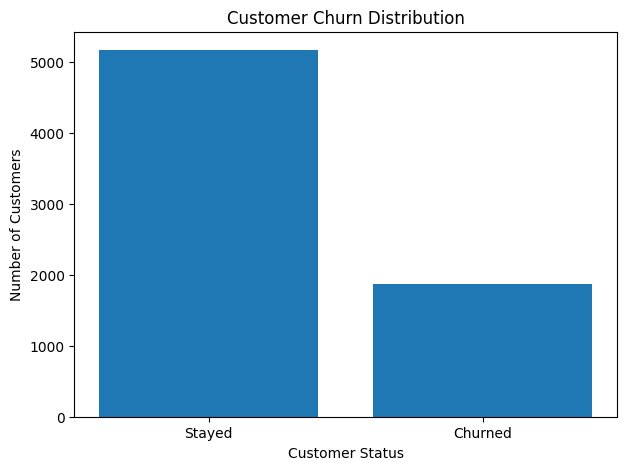

In [16]:
import matplotlib.pyplot as plt

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(["Stayed", "Churned"], churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()


CHURN PERCENTAGE

In [17]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Customer Churn Rate:")
print(f"Stayed: {churn_percentage.get(0, 0):.2f}%")
print(f"Churned: {churn_percentage.get(1, 0):.2f}%")

Customer Churn Rate:
Stayed: 73.42%
Churned: 26.58%



This percentage is important for the final report because it tells us the proportion of customers leaving.

CHURN BY CONTRACT TYPE

In [18]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


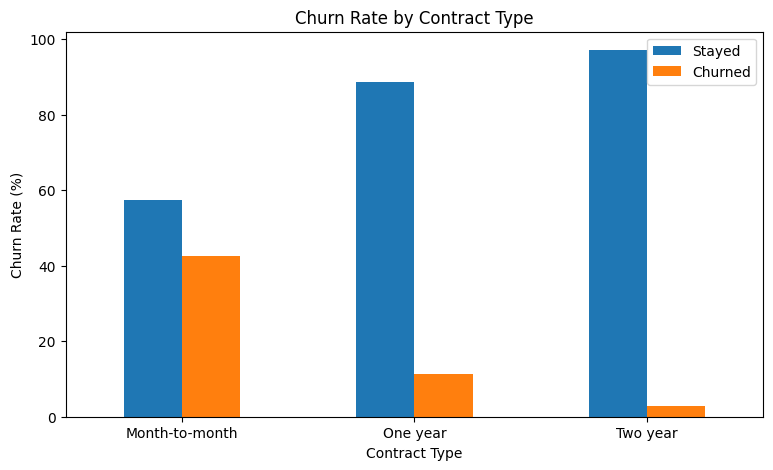

In [19]:
# WE HAVE TO VISUALIZE IT
contract_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()


CHURN BY INTERNET SERVICE

In [20]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                    0          1
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


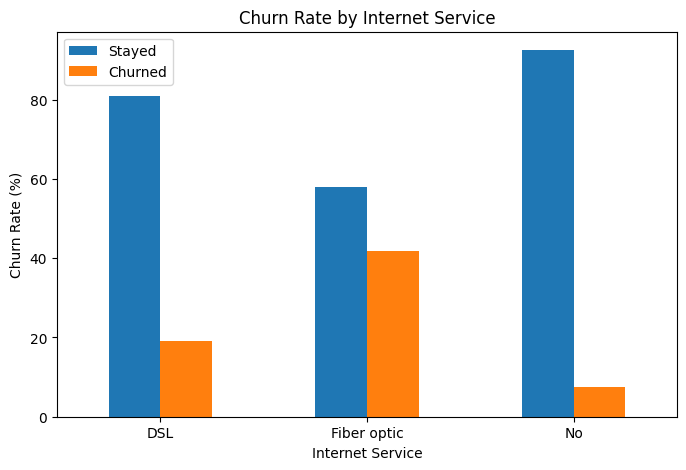

In [21]:
internet_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Churned"])
plt.show()


CHURN BY PAYMENT METHOD

In [22]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


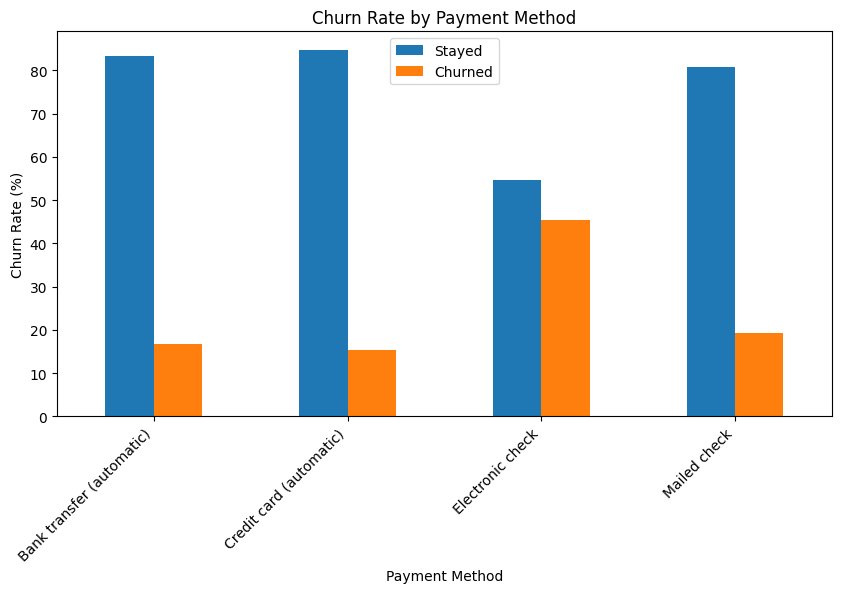

In [23]:
#VISUALIZE IT
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(["Stayed", "Churned"])
plt.show()


TENURE AND CHURN

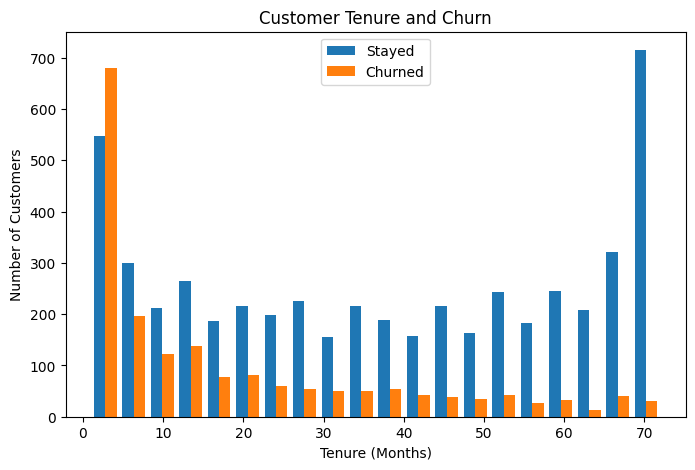

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    [df.loc[df["Churn"] == 0, "tenure"],
     df.loc[df["Churn"] == 1, "tenure"]],
    bins=20,
    label=["Stayed", "Churned"]
)

plt.title("Customer Tenure and Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend()
plt.show()


MONTHLY CHARGES AND CHURN

/tmp/ipykernel_968/178054436.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


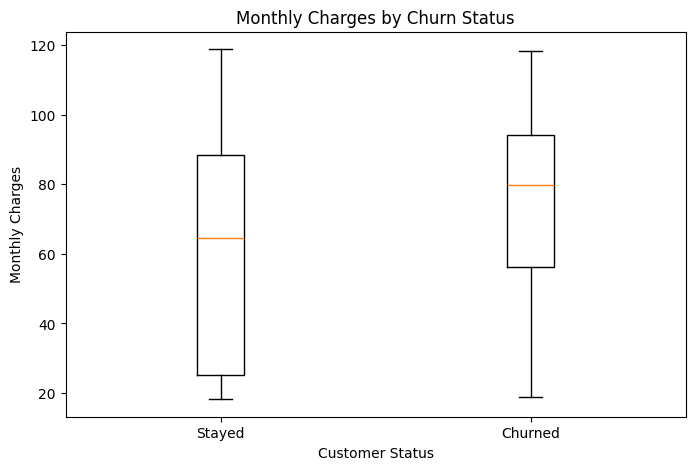

In [25]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df.loc[df["Churn"] == 0, "MonthlyCharges"],
        df.loc[df["Churn"] == 1, "MonthlyCharges"]
    ],
    labels=["Stayed", "Churned"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")
plt.show()


**Feature Preparation**

We are going to separate:

X = customer information/features
y = whether the customer churned

In [26]:
#Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [27]:
#Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



**Create the preprocessing pipeline**

 We'll use a Scikit-learn pipeline so that the exact same preprocessing is automatically applied when the Streamlit app receives a new customer.

In [28]:
#Creating the pipeline process
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.



**Split the data**

We'll use 80% for training and 20% for testing.

In [29]:
#Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 19)
Testing data: (1407, 19)



**The stratify=y part is important because it keeps the churn/stay proportions reasonably consistent in both sets.**


**TRAIN THE MODELS**


Now we'll compare three models, rather than assuming Random Forest is best.

In [30]:
#Import the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Models imported successfully.")

Models imported successfully.


In [31]:
#Create the three pipelines
logistic_model = pipeline = None

from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

print("Three model pipelines created.")

Three model pipelines created.


In [32]:
#Train all three
logistic_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


EVALUATING THE THREE MODELS

In [33]:
#Evaluate them
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Decision Tree,0.770434,0.571031,0.548128,0.559345
2,Random Forest,0.789623,0.634483,0.491979,0.554217


**WE HAVE TO SELECT THE BEST MODEL**

In [34]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Decision Tree,0.770434,0.571031,0.548128,0.559345
2,Random Forest,0.789623,0.634483,0.491979,0.554217


**For a churn problem, we'll pay particular attention to Recall and F1 Score, not just accuracy. Missing a customer who is actually going to churn can be costly for a telecom company.**

**Automatically select the best model**

In [35]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("Best model:", best_model_name)

Best model: Logistic Regression


In [36]:
best_model = models[best_model_name]

print("Selected model:", best_model)

Selected model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
 

**Detailed evaluation**

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

best_predictions = best_model.predict(X_test)

print("Classification Report")
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Stayed", "Churned"]
))

Classification Report
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [38]:
cm = confusion_matrix(y_test, best_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[917 116]
 [160 214]]


**ROC-AUC**

Because this is a binary classification problem, let's also calculate ROC-AUC

In [39]:
from sklearn.metrics import roc_auc_score

best_probabilities = best_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    best_probabilities
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.8359


**Visualize the confusion matrix**

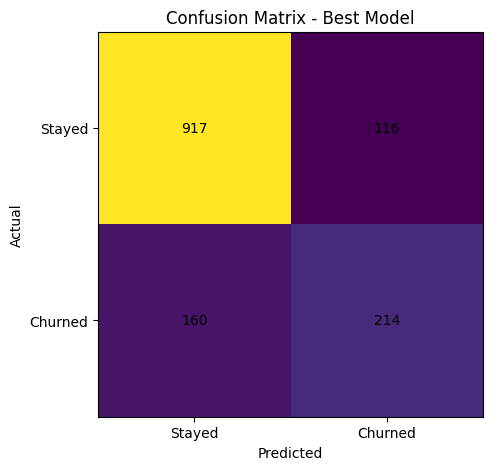

In [40]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Stayed", "Churned"])
plt.yticks([0, 1], ["Stayed", "Churned"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

**Save the entire pipeline**

In [41]:
import joblib

joblib.dump(
    best_model,
    "telecom_churn_model.pkl",
    compress=3
)

print("Complete churn pipeline saved successfully!")

Complete churn pipeline saved successfully!


**Test the saved pipeline**

In [42]:
loaded_model = joblib.load("telecom_churn_model.pkl")

test_prediction = loaded_model.predict(X_test.iloc[:5])
test_probability = loaded_model.predict_proba(X_test.iloc[:5])[:, 1]

print("Predictions:", test_prediction)
print("Churn probabilities:", test_probability)

Predictions: [0 1 0 0 0]
Churn probabilities: [0.01751303 0.59192131 0.00482103 0.20165167 0.1015014 ]


**Create the new app.py**

In [43]:
!pip install streamlit pandas numpy matplotlib scikit-learn==1.6.1 joblib==1.5.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 32.2 MB/s eta 0:00:00


In [44]:
import streamlit

print("Streamlit installed successfully!")
print(streamlit.__version__)

Streamlit installed successfully!
1.61.1


In [45]:
import os

print(os.listdir())

['.config', 'Telecom Churn Model1.csv', 'telecom_churn_model.pkl', 'sample_data']


In [46]:
!pip install pyngrok -q

In [47]:
!streamlit run app.py &> streamlit.log &

In [48]:
!ngrok config add-authtoken 3HrzFRuZHTAzlLyu49UNFcI7oPG_3KsMyhnCgtNzhd7N8tGXF

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [49]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Streamlit app:")
print(public_url)

Streamlit app:
NgrokTunnel: "https://washstand-unloved-pendant.ngrok-free.dev" -> "http://localhost:8501"


In [50]:
!cat streamlit.log

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [51]:
!ps aux | grep streamlit

root        2436  0.0  0.0   7372  3448 ?        S    00:56   0:00 /bin/bash -c ps aux | grep streamlit
root        2438  0.0  0.0   6480  2380 ?        S    00:56   0:00 grep streamlit


In [52]:
%%writefile app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# PAGE CONFIGURATION
# ============================================================

import streamlit as st

st.set_page_config(
    page_title="Telecom Churn Model",
    page_icon="📱",
    layout="wide"
)

st.title("📱 Telecom Churn Model")
st.markdown("""
**Author:** Ogu Ugochukwu Monday
**3MTT Fellow ID:** FE/25/7566333919
**Cohort:** NextGen Cohort Lagos
""")

st.info("""
**Educational Purpose:**
This project is designed for educational purposes as part of a 3MTT capstone project.
It demonstrates the use of machine learning to predict customer churn and should not
be used as the sole basis for real-world business decisions.
""")
st.markdown("### 📌 About the Project")

st.write("""
The Telecom Churn Model is a machine learning project developed to identify
telecom customers who may be at risk of leaving a service provider.

The model analyses customer characteristics such as tenure, contract type,
internet service, payment method, monthly charges and other service-related
information to estimate the likelihood of churn.

The goal is to help telecom businesses identify high-risk customers early
and support proactive customer retention strategies.
""")
# ============================================================
# METHODOLOGY
# ============================================================

with st.expander("🔬 Project Methodology"):

    st.markdown("""
    ### 1. Data Preparation

    The telecom customer dataset is loaded and cleaned before modelling.
    Customer ID fields are removed because they do not provide useful
    predictive information.

    Missing numerical values are handled using median imputation, while
    missing categorical values are handled using the most frequent value.

    ### 2. Feature Engineering

    Numerical variables are standardised using `StandardScaler`.

    Categorical variables are converted into numerical representations
    using `OneHotEncoder`.

    ### 3. Model Development

    A **Logistic Regression** algorithm is used to predict whether a
    customer is likely to churn.

    The dataset is divided into:

    - **80% training data**
    - **20% testing data**

    Stratified sampling is used to maintain the proportion of churned
    and retained customers in both datasets.

    ### 4. Model Evaluation

    The model is evaluated using:

    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - ROC-AUC
    - Confusion Matrix

    ### 5. Business Application

    The prediction can help telecom businesses identify customers who
    may be at higher risk of leaving and support proactive customer
    retention strategies.
    """)
# ============================================================
# LOAD DATASET
# ============================================================

@st.cache_data
def load_data():

    possible_files = [
        "Telecom Churn Model1.csv",
        "telecom_churn_model1.csv",
        "Telecom_Churn_Model1.csv"
    ]

    for file in possible_files:
        try:
            return pd.read_csv(file)
        except FileNotFoundError:
            continue

    return None


df = load_data()


if df is None:

    st.error(
        "Dataset not found. Please make sure "
        "'Telecom Churn Model1.csv' is in the same folder as app.py."
    )

    st.stop()


# ============================================================
# CLEAN DATA
# ============================================================

df.columns = df.columns.str.strip()

# Remove unnecessary customer ID column if present
id_columns = [
    "customerID",
    "CustomerID",
    "customer_id"
]

for col in id_columns:
    if col in df.columns:
        df = df.drop(columns=[col])


# Clean TotalCharges if it exists
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )


# ============================================================
# TARGET VARIABLE
# ============================================================

target = "Churn"

if target not in df.columns:

    st.error(
        f"The dataset does not contain the expected target column '{target}'."
    )

    st.write("Columns found in dataset:")
    st.write(df.columns.tolist())

    st.stop()


# Convert target to numeric
df[target] = df[target].map({
    "Yes": 1,
    "No": 0,
    1: 1,
    0: 0
})


df = df.dropna(subset=[target])


# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(columns=[target])
y = df[target]


# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()


# ============================================================
# PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# TRAIN MODEL
# ============================================================

with st.spinner("Training Logistic Regression model..."):

    model.fit(
        X_train,
        y_train
    )

# ============================================================
# MODEL EVALUATION
# ============================================================

y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header("👤 Customer Information")


# Helper function
def get_options(column):

    if column in df.columns:
        return sorted(
            df[column]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

    return []


# Create customer input dictionary
customer = {}
st.markdown("### 📊 Churn Overview")

churn_rate = df["Churn"].mean() * 100
total_customers = len(df)
churned_customers = int(df["Churn"].sum())
retained_customers = total_customers - churned_customers

col1, col2, col3 = st.columns(3)

with col1:
    st.metric(
        "Total Customers",
        f"{total_customers:,}"
    )

with col2:
    st.metric(
        "Churned Customers",
        f"{churned_customers:,}"
    )

with col3:
    st.metric(
        "Overall Churn Rate",
        f"{churn_rate:.1f}%"
    )
st.markdown("#### Customer Churn Distribution")

churn_chart = df["Churn"].value_counts()

chart_data = pd.DataFrame({
    "Customer Status": ["Stayed", "Churned"],
    "Customers": [
        churn_chart.get(0, 0),
        churn_chart.get(1, 0)
    ]
})

st.bar_chart(
    chart_data.set_index("Customer Status")
)
# ============================================================
# CUSTOMER INPUTS
# ============================================================

for column in X.columns:

    if column in numeric_features:

        minimum = float(df[column].min())
        maximum = float(df[column].max())
        default = float(df[column].median())

        customer[column] = st.sidebar.number_input(
            column,
            min_value=minimum,
            max_value=maximum,
            value=default
        )

    else:

        options = get_options(column)

        if options:

            customer[column] = st.sidebar.selectbox(
                column,
                options
            )
# ============================================================
# PREDICTION BUTTON
# ============================================================

st.markdown("---")

if st.button(
    "🔮 Predict Customer Churn",
    type="primary"
):

    customer_df = pd.DataFrame(
        [customer]
    )

    # Make prediction
    prediction = model.predict(
        customer_df
    )[0]

    # Get churn probability
    probability = model.predict_proba(
        customer_df
    )[0][1]

    churn_probability = probability * 100

    # ========================================================
    # RESULT
    # ========================================================

    st.subheader("Prediction Result")

    if prediction == 1:

        st.error(
            "⚠️ This customer is likely to churn."
        )

    else:

        st.success(
            "✅ This customer is likely to remain."
        )

    st.metric(
        "Churn Probability",
        f"{churn_probability:.2f}%"
    )

    # ========================================================
    # RISK LEVEL
    # ========================================================

    if churn_probability >= 70:

        st.warning(
            "Risk Level: HIGH"
        )

    elif churn_probability >= 40:

        st.info(
            "Risk Level: MEDIUM"
        )

    else:

        st.success(
            "Risk Level: LOW"
        )

    # ========================================================
    # BUSINESS RECOMMENDATION
    # ========================================================

    st.subheader("💡 Recommended Retention Actions")

    if prediction == 1:

        st.warning(
            "⚠️ Priority: This customer should be considered for retention action."
        )

        st.markdown("""
        **Recommended actions for this high-risk customer:**

        - **Personalised retention offer:** Consider targeted data,
          voice or subscription incentives.
        - **Customer service follow-up:** Contact the customer to
          identify and resolve service complaints.
        - **Affordable plan options:** Consider a plan that better
          matches the customer's needs and budget.
        - **Long-term contract incentive:** Offer suitable benefits
          for moving to a longer-term plan.
        - **Proactive engagement:** Monitor this customer closely
          because of the elevated churn probability.
        - **Service quality review:** Investigate network or service
          quality issues where relevant.
        """)

    else:

        st.success(
            "✅ This customer is currently at lower churn risk."
        )

        st.markdown("""
        **Recommended actions for this customer:**

        - Maintain good service quality.
        - Continue regular customer engagement.
        - Consider appropriate loyalty rewards.
        - Monitor changes in customer behaviour.
        - Encourage continued long-term customer relationships.
        """)

# ============================================================
# PROJECT DASHBOARD
# ============================================================

st.markdown("---")

st.subheader("📊 Project Dashboard")


col1, col2, col3 = st.columns(3)


with col1:
    st.metric(
        "Dataset Size",
        f"{len(df):,}"
    )


with col2:
    st.metric(
        "Features",
        len(X.columns)
    )


with col3:
    st.metric(
        "Model",
        "Logistic Regression"
    )


# ============================================================
# MODEL PERFORMANCE
# ============================================================

st.markdown("---")

st.subheader("📈 Model Performance")

metric1, metric2, metric3, metric4, metric5 = st.columns(5)

with metric1:
    st.metric(
        "Accuracy",
        f"{accuracy * 100:.2f}%"
    )

with metric2:
    st.metric(
        "Precision",
        f"{precision * 100:.2f}%"
    )

with metric3:
    st.metric(
        "Recall",
        f"{recall * 100:.2f}%"
    )

with metric4:
    st.metric(
        "F1 Score",
        f"{f1 * 100:.2f}%"
    )

with metric5:
    st.metric(
        "ROC-AUC",
        f"{roc_auc * 100:.2f}%"
    )
# ============================================================
# MODEL VISUALIZATIONS
# ============================================================

st.markdown("---")

st.subheader("📊 Model Evaluation Visualizations")

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

st.markdown("### 🔲 Confusion Matrix")

fig_cm, ax_cm = plt.subplots()

ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=["Stayed", "Churned"]
).plot(ax=ax_cm)

ax_cm.set_title("Confusion Matrix")

st.pyplot(fig_cm)

plt.close(fig_cm)


# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

st.markdown("### 📈 ROC Curve")

fig_roc, ax_roc = plt.subplots()

RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    ax=ax_roc
)

ax_roc.set_title(
    f"ROC Curve (AUC = {roc_auc:.3f})"
)

st.pyplot(fig_roc)

plt.close(fig_roc)

# ============================================================
# CONFUSION MATRIX
# ============================================================

st.subheader("🔲 Confusion Matrix")

confusion_data = pd.DataFrame(
    conf_matrix,
    index=["Actual Stayed", "Actual Churned"],
    columns=["Predicted Stayed", "Predicted Churned"]
)

st.dataframe(
    confusion_data,
    use_container_width=True
)
# ============================================================
# BUSINESS INSIGHTS
# ============================================================

st.markdown("---")

st.subheader("💼 Business Insights")

st.markdown(f"""
Based on the dataset and model results:

- The overall customer churn rate is **{churn_rate:.1f}%**.
- The model achieved an accuracy of **{accuracy * 100:.2f}%**.
- The model's precision is **{precision * 100:.2f}%**.
- The model's recall is **{recall * 100:.2f}%**.
- The model's F1 score is **{f1 * 100:.2f}%**.
- The ROC-AUC score is **{roc_auc * 100:.2f}%**.

These results demonstrate how machine learning can be used as a
decision-support tool for identifying customers who may be at risk
of churn.

Businesses can use these predictions to prioritise customer
engagement, investigate service issues and develop appropriate
retention strategies.
""")
# ============================================================
# CONCLUSION
# ============================================================

st.markdown("---")

st.subheader("🏁 Conclusion")

st.markdown("""
This Telecom Churn Prediction Model demonstrates how machine learning
can be used to identify customers who may be at risk of leaving a
telecom service provider.

The Logistic Regression model achieved an accuracy of **80.55%** and
a ROC-AUC score of **84.19%**, demonstrating good overall predictive
performance.

The application goes beyond prediction by providing churn
probabilities, customer risk levels, and recommended retention actions.

These insights can help telecom businesses identify high-risk
customers and support proactive customer retention strategies.

**Note:** This application is designed for educational purposes and
should be used as a decision-support tool rather than the sole basis
for real-world business decisions.
""")
# ============================================================
# FOOTER
# ============================================================

st.markdown("---")

st.caption(
    "© 2026 Ogu Ugochukwu Monday. "
    "This project is designed for Educational purposes."
)

Writing app.py


In [53]:
import os

print(os.listdir())

['.config', 'Telecom Churn Model1.csv', 'app.py', 'telecom_churn_model.pkl', 'streamlit.log', 'sample_data']


In [54]:
!python -m py_compile app.py

In [55]:
!pkill -f "streamlit run app.py" || true

^C


In [56]:
!streamlit run app.py --server.port 8503 > streamlit.log 2>&1 &

In [57]:
!cat streamlit.log

In [58]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8503)

print(public_url)

NgrokTunnel: "https://washstand-unloved-pendant.ngrok-free.dev" -> "http://localhost:8503"


In [59]:
!grep -n "Recommended Retention Actions" app.py

530:    st.subheader("💡 Recommended Retention Actions")


In [60]:
with open("/content/app.py", "r") as f:
    print(f.read())


import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ============================================================
# PAGE CONFIGURATION
# ============================================================

import streamlit as st

st.set_page_config(
    page_title="Telecom Churn Model",
    page_icon="📱",
    layout="wide"
)

st.title("📱 Telecom Churn Model")
st.markdown("""
**Author:** Ogu Ugochukwu Monday  
**3MTT Fellow ID:** FE/25/7566333919  
**Cohort:** NextGen C

In [61]:
%%writefile README.md

# Telecom Churn Prediction Model

## 📱 Project Overview

The **Telecom Churn Prediction Model** is a machine learning application developed to predict whether a telecom customer is likely to leave a service provider.

The project uses customer information such as tenure, contract type, internet service, payment method, monthly charges, and other service-related characteristics to estimate the probability of customer churn.

The application was developed as part of a **3MTT Capstone Project**.

## 👤 Author

**Name:** Ogu Ugochukwu Monday
**3MTT Fellow ID:** FE/25/7566333919
**Cohort:** NextGen Cohort Lagos

## 🎯 Project Objective

The main objective of this project is to develop a machine learning model that can:

- Predict whether a customer is likely to churn.
- Estimate the probability of customer churn.
- Classify customers into low, medium, and high-risk categories.
- Provide recommended customer retention actions.
- Demonstrate how machine learning can support telecom business decisions.

## 🗂️ Dataset

The project uses a telecom customer churn dataset containing customer demographic, account, service, and billing information.

The target variable is:

- `Churn = Yes` → Customer churned
- `Churn = No` → Customer remained

Customer identification fields such as `customerID` are removed because they do not provide useful predictive information.

## 🔧 Technologies Used

- Python
- Pandas
- Scikit-learn
- Streamlit
- Matplotlib

## 🤖 Machine Learning Approach

The project uses **Logistic Regression** for binary classification.

### Data preprocessing

The preprocessing pipeline includes:

1. Numerical missing-value imputation using the median.
2. Categorical missing-value imputation using the most frequent value.
3. Numerical feature scaling using `StandardScaler`.
4. Categorical feature encoding using `OneHotEncoder`.

A `ColumnTransformer` and Scikit-learn `Pipeline` are used to combine the preprocessing and machine-learning steps.

## 📊 Train/Test Split

The dataset is divided into:

- **80% training data**
- **20% testing data**

Stratified sampling is used to preserve the distribution of churn and non-churn customers.

## 📈 Model Evaluation

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

## 📊 Model Results

The Logistic Regression model was evaluated on the test dataset using multiple performance metrics.

| Metric | Result |
|---|---:|
| Customer Churn Rate | 26.5% |
| Accuracy | 80.55% |
| Precision | 65.72% |
| Recall | 55.88% |
| F1 Score | 60.40% |
| ROC-AUC | 84.19% |

The model achieved an accuracy of **80.55%** and an ROC-AUC of **84.19%**, demonstrating good overall ability to distinguish between customers who are likely to churn and those who are likely to remain.

The precision score of **65.72%** indicates that a substantial proportion of customers predicted as churners were actual churners. The recall score of **55.88%** indicates that the model identified more than half of the customers who actually churned.

The F1 score of **60.40%** reflects a moderate balance between precision and recall.

Although the results are promising, the recall score indicates that further model improvement could help identify more customers at risk of churn.
## 📊 Application Features

The Streamlit application provides:

### Customer Churn Overview

Displays:

- Total customers
- Number of churned customers
- Overall churn rate
- Customer churn distribution

### Customer Prediction

Users can enter customer information through the sidebar and generate:

- Churn prediction
- Churn probability
- Risk classification

### Risk Classification

Customers are classified as:

- **LOW RISK:** below 40%
- **MEDIUM RISK:** 40%–69.99%
- **HIGH RISK:** 70% and above

### Retention Recommendations

The application provides suggested actions for customers identified as having elevated churn risk.

## 💼 Business Value

A churn prediction system can help telecom businesses:

- Identify customers who may be at risk.
- Prioritise retention efforts.
- Investigate possible service problems.
- Develop personalised retention strategies.
- Improve customer engagement.

## 🚀 How to Run the Application

Install the required packages:

```bash
pip install streamlit pandas scikit-learn matplotlib

⚠️ Disclaimer

This project is developed for educational purposes as part of a 3MTT capstone project.

The predictions generated by the model should not be used as the sole basis for real-world customer or business decisions.

🏁 Conclusion

This project demonstrates how machine learning can be applied to telecom customer data to predict churn and support proactive customer retention.

The combination of data preprocessing, Logistic Regression, model evaluation, probability-based risk classification, and business recommendations provides an end-to-end example of a practical machine-learning application.

Writing README.md


In [62]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
matplotlib

Writing requirements.txt


In [63]:
import shutil

shutil.copy("app.py", "app_final_working.py")

print("Backup created successfully.")

Backup created successfully.


In [64]:
import os

for file in os.listdir():
    if file in [
        "app.py",
        "app_final_working.py",
        "requirements.txt",
        "Telecom Churn Model1.csv"
    ]:
        print("✅", file)

✅ Telecom Churn Model1.csv
✅ app.py
✅ app_final_working.py
✅ requirements.txt


In [68]:
import os

print([f for f in os.listdir('/content') if f.endswith('.ipynb')])

[]
